# Jackknife Covariance for Heracles

This notebook demonstrates how to connect *Heracles* with *SkySegmentor* and *DICES* to compute jackknife covariance matrices for the angular power spectrum of a given map

## Installs

It is good to start by creating and activating the Growth in the Dark conda environment:
```Python
git pull https://github.com/GrowInTheDark/onboarding
mamba env create -f environment.yml
conda activate gitd
conda config --env --append channels conda-forge
conda config --env --remove channels defaults
```

You will also need to install the following packages to run this notebook:
```Python
pip install https://github.com/knaidoo29/SkySegmentor
pip install https://github.com/knaidoo29/Euclid_Covariance_Pipeline.git
```

## Setup

Some required imports, nothing fancy.

In [27]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import matplotlib as mpl
import healpy as hps
import math
import heracles
import skysegmentor
import dices

If there is an import error on the last line of the previous block, it means you need to install the `ipywidgets` package.

## Perform the segmentation

In order to produce a map of jackknife regions, we need to segment the mask produced in our previous example notebook. We will use the `SkySegmentor` package to do this.

In [2]:
#Load the footprint of the past example
footprint = hp.read_map('example-footprint.fits')

#Segment the sky
njk = 5  # Number of jackknife regions
jkmap = skysegmentor.segmentmapN(footprint, njk)

In [3]:
len(footprint)

12582912

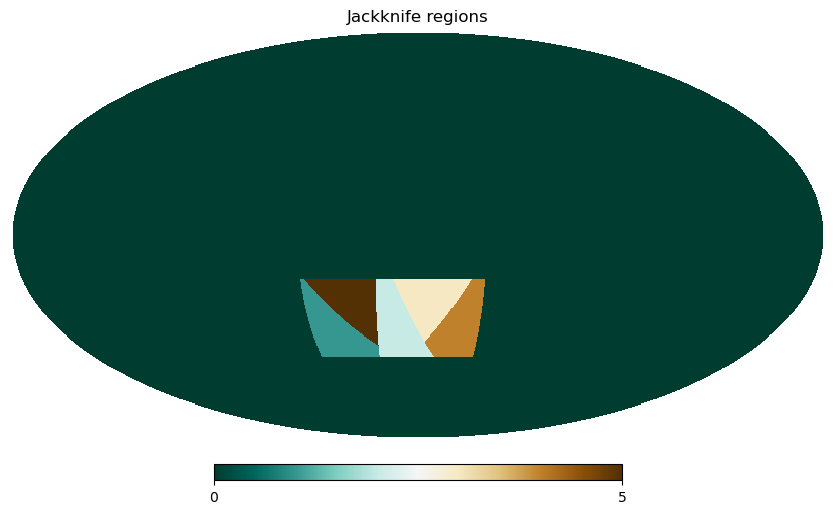

In [4]:
hp.mollview(jkmap, title='Jackknife regions', cmap='BrBG_r', min=0, max=njk)

## Compute the Jackknife covariance

Let us start by loading the previously generated mask and map.
We will also generate our configuration file for *DICES*.

In [5]:
data_maps = heracles.read_maps("example-maps.fits")
vis_maps = heracles.read_maps("example-vmaps.fits")

In [19]:
config = {}
config['Nside'] = 1024
config['Njk'] = 5
config['Output'] = {}
config['Output']['save'] = False
config['Output']['path'] = './tests/'
config['Fields'] = {}
config['Fields']['Nbins'] = 6
config['Fields']['Keys'] = {}
config['Fields']['Keys']['TomoBin'] = 'TOM_BIN_ID'
config['Fields']['Keys']['Pos'] = {}
config['Fields']['Keys']['Pos']['Ra'] = 'RA'
config['Fields']['Keys']['Pos']['Dec'] = 'DEC'
config['Fields']['Keys']['She'] = {}
config['Fields']['Keys']['She']['Ra'] = 'RA'
config['Fields']['Keys']['She']['Dec'] = 'DEC'
config['Fields']['Keys']['She']['E1'] = 'E1'
config['Fields']['Keys']['She']['E2'] = 'E2'
config['Fields']['Keys']['She']['Weights'] = 'W'
config['Cov'] = {}
config['Cov']['Lmin'] = 10
config['Cov']['Lmax'] = 1024
config['Cov']['Lbin'] = 10
config['Cov']['Logbins'] = True
config['DICES'] = {}
config['DICES']['mask_correction'] = True
config['DICES']['shrinkage'] = True
config['DICES']['delete2_correction'] = True

Now initialize the `DICES` class and compute the jackknife covariance matrix.

In [20]:
DICESObj = dices.DICES(data_maps,
                       jkmap,
                       vis_maps, 
                       config) 

In [23]:
cov = DICESObj.get_dices_cov()
target_cov = DICESObj.get_target_cov()

 - Biases for entire region: [2.60764343e-09 2.63857948e-09 2.64354959e-09 2.64574019e-09
 2.64665887e-09 2.62070693e-09] [2.16967080e-10 2.19598625e-10 2.20032237e-10 2.20420081e-10
 2.20572287e-10 2.18485533e-10]
Computing Ngal and Wmean/var for Jackknife regions
 - Biases for jackknife regions: [[2.0861419329517416e-09, 2.1108910951506945e-09, 2.114867241473658e-09, 2.1166197430753237e-09, 2.117354697602692e-09, 2.0965928704726455e-09], [2.0864218478737203e-09, 2.1111743308725175e-09, 2.1151510107079283e-09, 2.1169037474572323e-09, 2.1176388005995295e-09, 2.096874187683373e-09], [2.085554111615587e-09, 2.1102963001348674e-09, 2.1142713260816917e-09, 2.1160233338733163e-09, 2.1167580813093328e-09, 2.096002104330119e-09], [2.08616992444394e-09, 2.1109194187228773e-09, 2.1148956183970854e-09, 2.1166481435135147e-09, 2.117383107902376e-09, 2.0966210021937186e-09], [2.0862858891973307e-09, 2.1110367592362036e-09, 2.115013179936997e-09, 2.1167658024717338e-09, 2.117500807715351e-09, 2.096

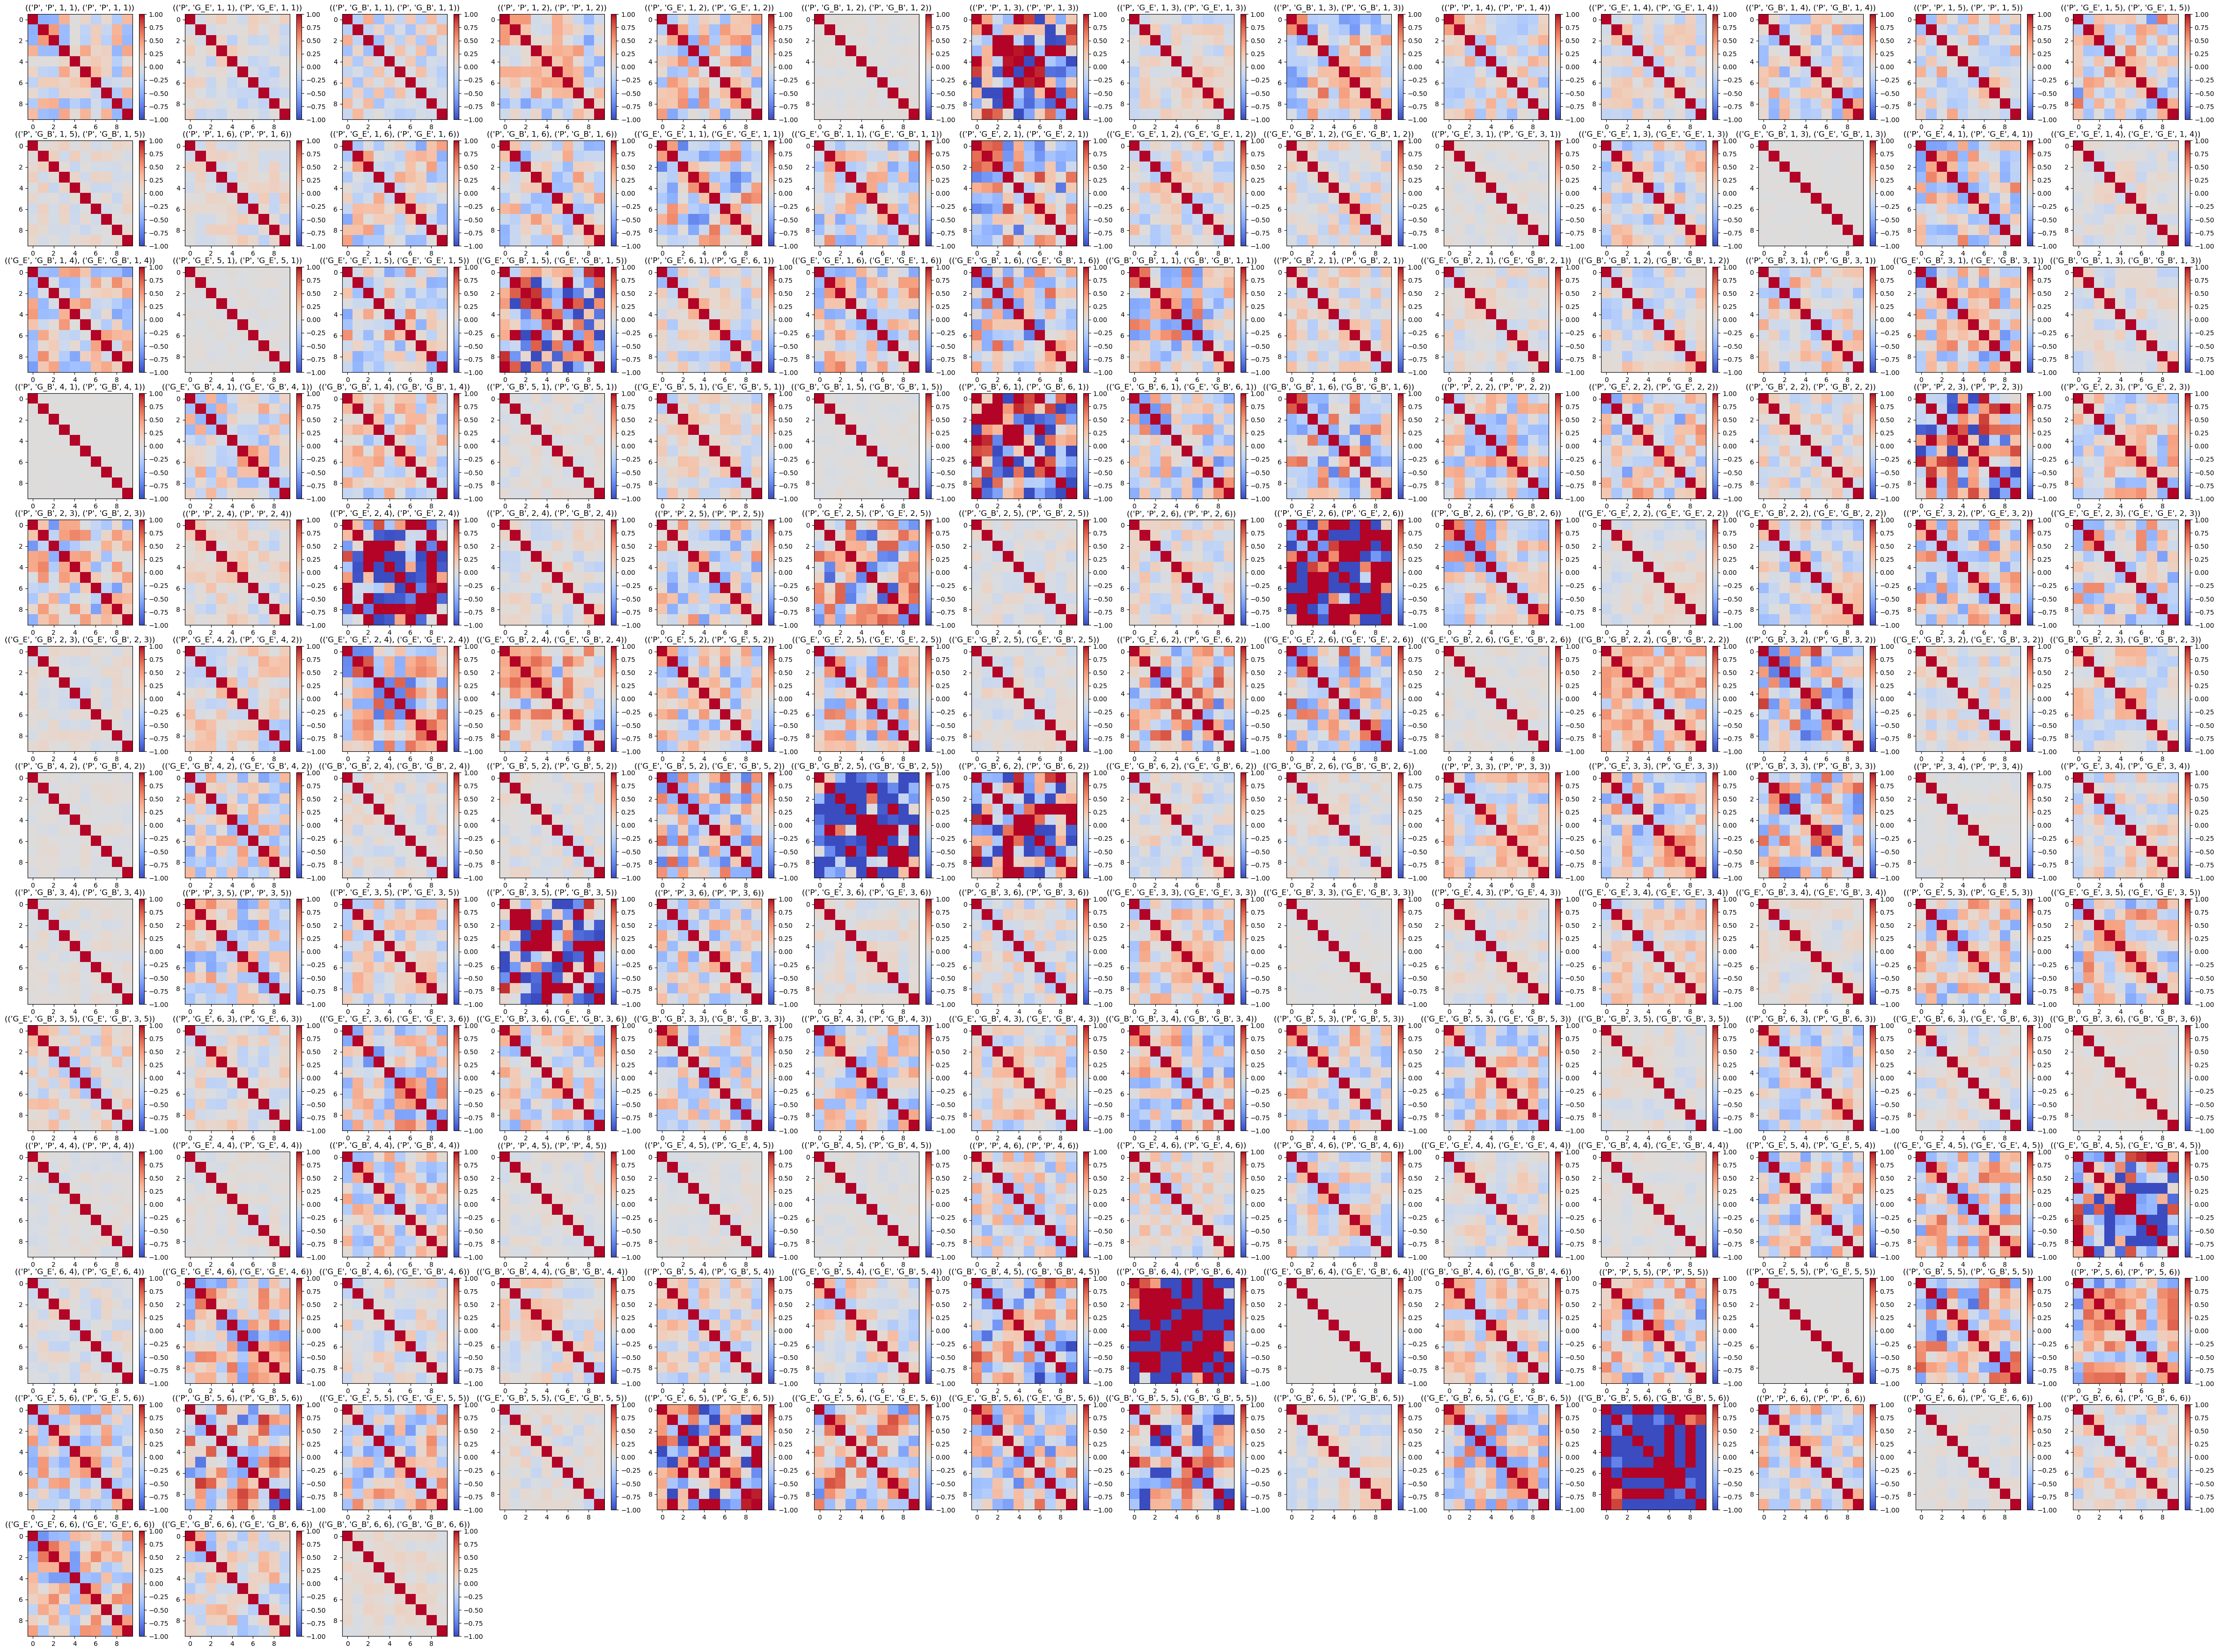

In [35]:
# Calculate the number of rows and columns to make the plot as square as possible
num_plots = len(cov)
num_cols = math.ceil(math.sqrt(num_plots))
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(60, 45))

# Flatten axes array for easy iteration
axes = axes.flatten()

for ax, (key, value) in zip(axes, cov.items()):
    err = np.sqrt(np.diag(value))
    value = value / np.outer(err, err)
    im = ax.imshow(value, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_title(f'{key}')
    fig.colorbar(im, ax=ax)


# Hide any unused subplots
for ax in axes[len(cov):]:
    ax.axis('off')

In [36]:
from heracles.twopoint import binned_cls
cls = DICESObj.get_cls()[0]
cqs = binned_cls(cls, DICESObj.ledges)
for key in cqs.keys():
    cqs[key] = np.array([binCl[1] for binCl in cqs[key]])

/tmp/ipykernel_73724/1982870800.py:24: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.loglog()
/tmp/ipykernel_73724/1982870800.py:30: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


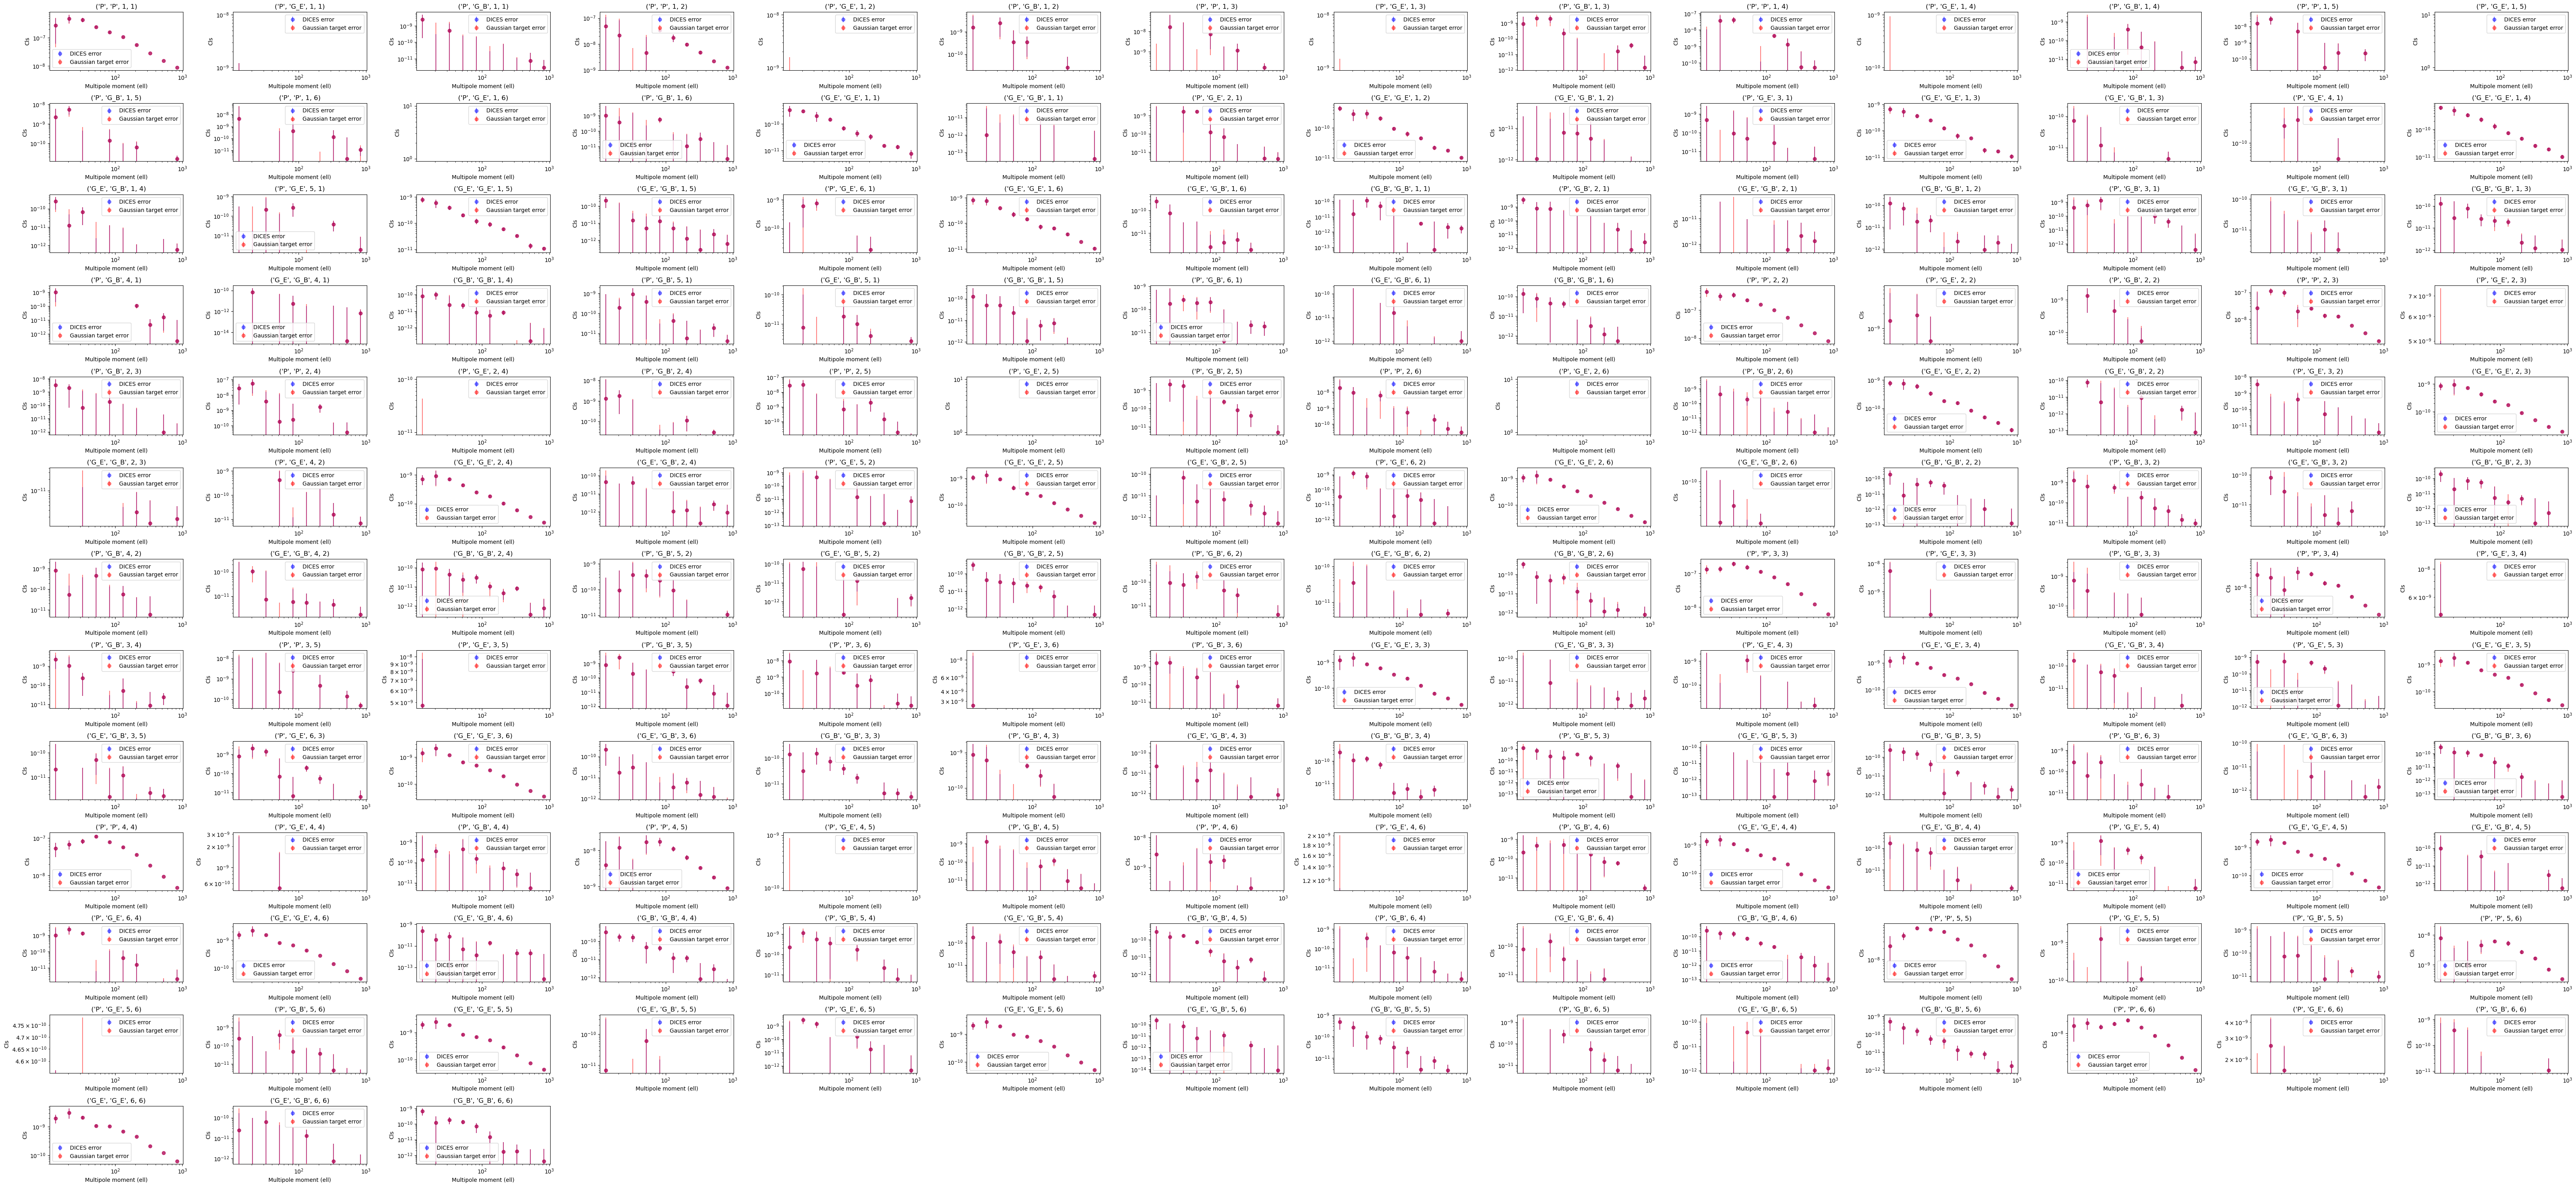

In [31]:
# Determine the number of subplots needed
num_plots = len(cls)
num_cols = math.ceil(math.sqrt(num_plots))
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(65, 30))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot each Cls with error bars
for ax, (key, value) in zip(axes, cqs.items()):
    ell = DICESObj.lgrid
    c = cov[(key, key)]
    t = target_cov[(key, key)]
    err = np.sqrt(np.diag(c))
    err_target = np.sqrt(np.diag(t))
    ax.errorbar(ell, value, yerr=err, fmt='bo', alpha=0.5, label="DICES error")
    ax.errorbar(ell, value, yerr=err_target, fmt='ro', alpha=0.5, label=f'Gaussian target error')
    ax.set_title(f'{key}')
    ax.set_xlabel('Multipole moment (ell)')
    ax.set_ylabel('Cls')
    ax.legend()
    ax.loglog()

# Hide any unused subplots
for ax in axes[len(cls):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### Thinking of parallelization

The `DICES` pipeline can be broken in 4 parts:
1. Compute the delete 1 region Cls
2. Compute the delete 1 jackknife covariance matrix 
3. Compute the delete 2 region Cls
4. Compute the delete 2 correction to the jackknife covariance matrix

Thus steps 1 and 3 can be parallelized as follows:

In [ ]:
import os

# Paralleliza this process using many jobs
for jk in range(1, DICESObj.JackNjk + 1):
    data_fname = DICESObj.output_path + "cls/cls_njk_%i_jkid_%i.fits" % (
        DICESObj.JackNjk,
        jk,
    )
    mask_fname = DICESObj.output_path + "cls/mls_njk_%i_jkid_%i.fits" % (
        DICESObj.JackNjk,
        jk,
    )
    bias = DICESObj._get_bias()
    biasjk = DICESObj._get_delete1_bias()
    cls, cls_mm = DICESObj._get_delete1_cls(jk)
    cls_wbias = dices.add_to_Cls(cls, bias)
    cls_cbias = dices.sub_to_Cls(cls_wbias, biasjk[jk])
    if DICESObj.mask_correction:
        cls_cbias = self._correct_data_cls_mask(cls_cbias, cls_mm)

    heracles.write_cls(data_fname, cls_cbias)
    heracles.write_cls(mask_fname, cls_mm)

In [ ]:
# Load the Cls in a different job
Clsjks = {}
for jk in range(1, njk+1):
    data_fname = DICESObj.output_path + "cls/cls_njk_%i_jkid_%i.fits" % (
        DICESObj.JackNjk,
        jk,
    )
    Clsjks[jk] = dices.get_Cls(data_fname, None)

# And use them to compute the covariance
dices_cov, _ = DICESObj._get_delete1_cov(
    Clsjks,
    shrink=True,
    )

# This approach can be extended to the delete2 correction